In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-100-indian-universities-dataset/NIRF ranking 2022.csv
/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2021.csv
/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2023.csv
/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2025.csv
/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2020.csv
/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2024.csv


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

# Data OverView

<table>
  <tr>
    <th>Column Name</th>
    <th>Full Meaning</th>
    <th>Explanation</th>
  </tr>
  <tr>
    <td><b>Institute ID</b></td>
    <td>Institution Identifier</td>
    <td>Unique ID assigned to each institution by NIRF</td>
  </tr>
  <tr>
    <td><b>Institute Name</b></td>
    <td>Institution Name</td>
    <td>Official name of the university or institute</td>
  </tr>
  <tr>
    <td><b>TLR</b></td>
    <td>Teaching, Learning & Resources</td>
    <td>Measures faculty quality, student strength, and infrastructure</td>
  </tr>
  <tr>
    <td><b>RPC</b></td>
    <td>Research & Professional Practice</td>
    <td>Reflects research output, publications, patents, and impact</td>
  </tr>
  <tr>
    <td><b>GO</b></td>
    <td>Graduation Outcomes</td>
    <td>Evaluates placements, higher studies, and student success</td>
  </tr>
  <tr>
    <td><b>OI</b></td>
    <td>Outreach & Inclusivity</td>
    <td>Measures diversity, gender balance, and regional inclusivity</td>
  </tr>
  <tr>
    <td><b>PERCEPTION</b></td>
    <td>Perception Score</td>
    <td>Reputation score from academics and employers</td>
  </tr>
  <tr>
    <td><b>City</b></td>
    <td>City Location</td>
    <td>City where the institution is located</td>
  </tr>
  <tr>
    <td><b>State</b></td>
    <td>State Location</td>
    <td>Indian state or union territory of the institution</td>
  </tr>
  <tr>
    <td><b>Score</b></td>
    <td>Overall NIRF Score</td>
    <td>Final weighted score calculated from all parameters</td>
  </tr>
  <tr>
    <td><b>Rank</b></td>
    <td>NIRF Rank</td>
    <td>Final national rank assigned for that year</td>
  </tr>
  <tr>
    <td><b>Year</b></td>
    <td>Ranking Year</td>
    <td>Year of NIRF ranking (2020–2025)</td>
  </tr>
</table>


In [3]:
path_2020 = "/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2020.csv"
path_2021 = "/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2021.csv"
path_2022 = "/kaggle/input/top-100-indian-universities-dataset/NIRF ranking 2022.csv"
path_2023 = "/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2023.csv"
path_2024 = "/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2024.csv"
path_2025 = "/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2025.csv"


df_2020 = pd.read_csv(path_2020)
df_2021 = pd.read_csv(path_2021)
df_2022 = pd.read_csv(path_2022)
df_2023 = pd.read_csv(path_2023)
df_2024 = pd.read_csv(path_2024)
df_2025 = pd.read_csv(path_2025)


In [4]:
df_2020.head(3)

,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank
0,IR-O-U-0456,Indian Institute of Technology Madras,85.61,92.51,86.32,63.57,97.13,Chennai,Tamil Nadu,86.76,1
1,IR-O-U-0220,Indian Institute of Science,79.13,91.48,78.23,58.39,100.00,Bengaluru,Karnataka,82.67,2
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.52,87.81,80.86,57.48,91.96,Mumbai,Maharashtra,82.52,3


**Since the year information is not always present inside the CSV files,
we explicitly add a Year column to each dataframe before combining them**

In [5]:
df_2020["Year"] = 2020
df_2021["Year"] = 2021
df_2022["Year"] = 2022
df_2023["Year"] = 2023
df_2024["Year"] = 2024
df_2025["Year"] = 2025


**After adding the year column, all datasets are vertically stacked using pd.concat.
This creates a unified dataset where each row represents one institution in one year.**

In [6]:
df = pd.concat(
    [df_2020, df_2021, df_2022, df_2023, df_2024, df_2025],
    ignore_index=True
)


In [7]:
print("2020 columns:", df_2020.shape[1])
print("2021 columns:", df_2021.shape[1])
print("2022 columns:", df_2022.shape[1])
print("2023 columns:", df_2023.shape[1])
print("2024 columns:", df_2024.shape[1])
print("2025 columns:", df_2025.shape[1])


2020 columns: 12
2021 columns: 12
2022 columns: 12
2023 columns: 12
2024 columns: 29
2025 columns: 12


In [8]:
print("Shape of combined dataset:", df.shape)
df.head()


Shape of combined dataset: (600, 29)


,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank,Year,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,IR-O-U-0456,Indian Institute of Technology Madras,85.61,92.51,86.32,63.57,97.13,Chennai,Tamil Nadu,86.76,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IR-O-U-0220,Indian Institute of Science,79.13,91.48,78.23,58.39,100.00,Bengaluru,Karnataka,82.67,2,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.52,87.81,80.86,57.48,91.96,Mumbai,Maharashtra,82.52,3,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IR-O-I-1074,Indian Institute of Technology Delhi,84.02,84.46,75.07,67.97,93.89,New Delhi,Delhi,81.75,4,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IR-O-I-1075,Indian Institute of Technology Kanpur,80.50,75.23,80.74,56.97,79.30,Kanpur,Uttar Pradesh,76.50,5,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.columns


Index(['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI',
       'PERCEPTION', 'City', 'State', 'Score', 'Rank', 'Year', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27'],
      dtype='object')

# Data Cleaning & Validation

**Some CSV files contain extra empty columns caused by formatting issues.
These columns typically appear as Unnamed and contain no meaningful data**

In [10]:
unnamed_cols=[col for col in df.columns if "Unnamed" in col]
unnamed_cols

['Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27']

In [11]:
df.drop(columns=unnamed_cols, inplace=True)

In [12]:
print("Shape after cleaning:", df.shape)
df.head()


Shape after cleaning: (600, 12)


,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank,Year
0,IR-O-U-0456,Indian Institute of Technology Madras,85.61,92.51,86.32,63.57,97.13,Chennai,Tamil Nadu,86.76,1,2020
1,IR-O-U-0220,Indian Institute of Science,79.13,91.48,78.23,58.39,100.00,Bengaluru,Karnataka,82.67,2,2020
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.52,87.81,80.86,57.48,91.96,Mumbai,Maharashtra,82.52,3,2020
3,IR-O-I-1074,Indian Institute of Technology Delhi,84.02,84.46,75.07,67.97,93.89,New Delhi,Delhi,81.75,4,2020
4,IR-O-I-1075,Indian Institute of Technology Kanpur,80.50,75.23,80.74,56.97,79.30,Kanpur,Uttar Pradesh,76.50,5,2020


In [13]:
df.isnull().sum()

Institute ID      0
Institute Name    0
TLR               0
RPC               0
GO                0
OI                0
PERCEPTION        0
City              0
State             0
Score             0
Rank              0
Year              0
dtype: int64

In [14]:
df.dtypes


Institute ID       object
Institute Name     object
TLR               float64
RPC               float64
GO                float64
OI                float64
PERCEPTION        float64
City               object
State              object
Score             float64
Rank                int64
Year                int64
dtype: object

In [15]:
df.columns=(
    df.columns
        .str.strip()
        .str.lower()
    
        .str.replace(" ","_")
)

In [16]:
df.columns

Index(['institute_id', 'institute_name', 'tlr', 'rpc', 'go', 'oi',
       'perception', 'city', 'state', 'score', 'rank', 'year'],
      dtype='object')

In [17]:
df["score"].describe()


count    600.000000
mean      54.263017
std        9.461456
min       41.100000
25%       47.965000
50%       51.975000
75%       57.670000
max       87.590000
Name: score, dtype: float64

In [18]:
df["rank"].describe()


count    600.0000
mean      50.4700
std       28.8791
min        1.0000
25%       25.7500
50%       50.5000
75%       75.2500
max      100.0000
Name: rank, dtype: float64

**Basic validation checks confirm that score and rank values fall within expected NIRF-defined ranges.**

# EDA

## Understanding the Overall Ranking Landscape

In [19]:
df.shape, df["year"].nunique(), df["institute_name"].nunique()


((600, 12), 6, 171)

**The combined dataset consists of 600 observations covering 171 unique institutions across 6 years (2020–2025)**

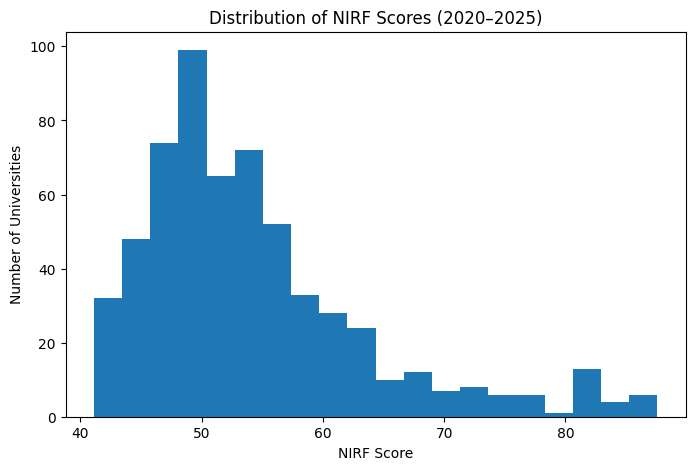

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=20)
plt.xlabel("NIRF Score")
plt.ylabel("Number of Universities")
plt.title("Distribution of NIRF Scores (2020–2025)")
plt.show()


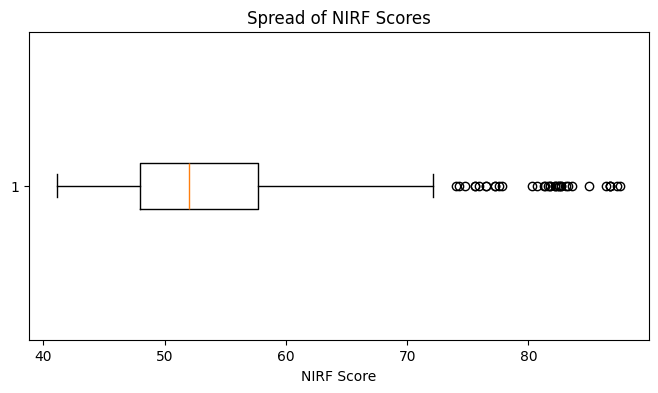

In [21]:
plt.figure(figsize=(8,4))
plt.boxplot(df["score"], vert=False)
plt.xlabel("NIRF Score")
plt.title("Spread of NIRF Scores")
plt.show()


**The boxplot reveals a narrow interquartile range, suggesting intense competition among mid-ranked institutions**

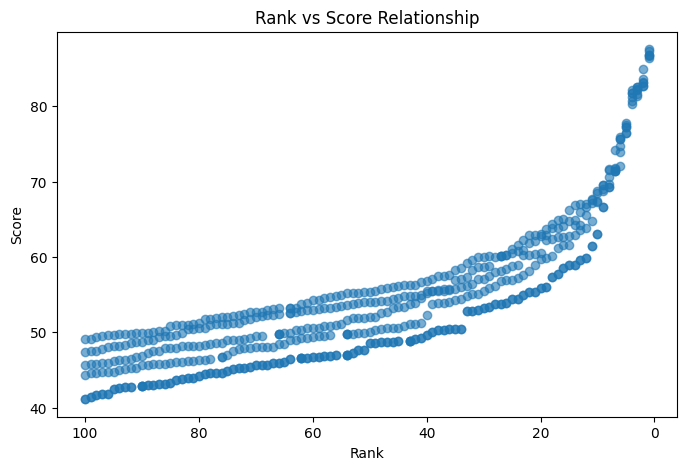

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df["rank"], df["score"], alpha=0.6)
plt.xlabel("Rank")
plt.ylabel("Score")
plt.title("Rank vs Score Relationship")
plt.gca().invert_xaxis() 
plt.show()


**The rank–score relationship shows a clear inverse pattern: higher scores correspond to better ranks**

## Top vs Mid vs Lower Ranked Universities

**We are testing how big is the average score gap?**

In [23]:

top_10 = df[df["rank"] <= 10]["score"]
top_50 = df[df["rank"] <= 50]["score"]
rest = df[df["rank"] > 50]["score"]

top_10.mean(), top_50.mean(), rest.mean()


(np.float64(76.26266666666665),
 np.float64(60.489399999999996),
 np.float64(48.03663333333334))

**Do Top, Mid, and Lower ranked universities overlap in score?**

<Figure size 800x500 with 0 Axes>

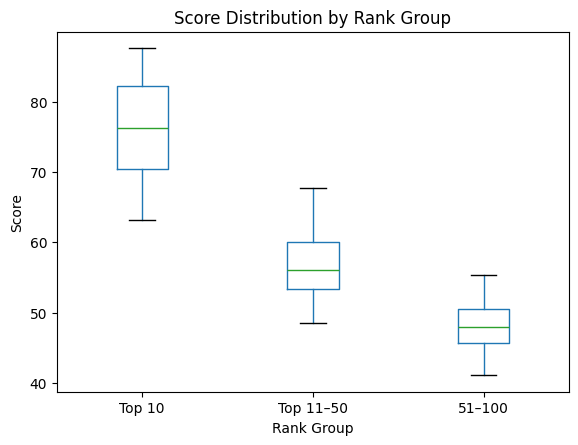

In [24]:
df["rank_group"] = pd.cut(
    df["rank"],
    bins=[0, 10, 50, 100],
    labels=["Top 10", "Top 11–50", "51–100"]
)

plt.figure(figsize=(8,5))
df.boxplot(column="score", by="rank_group", grid=False)
plt.title("Score Distribution by Rank Group")
plt.suptitle("")
plt.xlabel("Rank Group")
plt.ylabel("Score")
plt.show()


**A clear separation is observed between different rank groups.
The Top 10 universities achieve an average score of approximately 76, significantly higher than the Top 11–50 group (60) and the 51–100 group (48)**

**The boxplot analysis further shows minimal overlap between these groups, indicating that NIRF rankings effectively capture meaningful performance tiers rather than arbitrary rank ordering**

## Parameter Behavior & Variability

**Do all parameters behave similarly, or do some show more variation than others?**

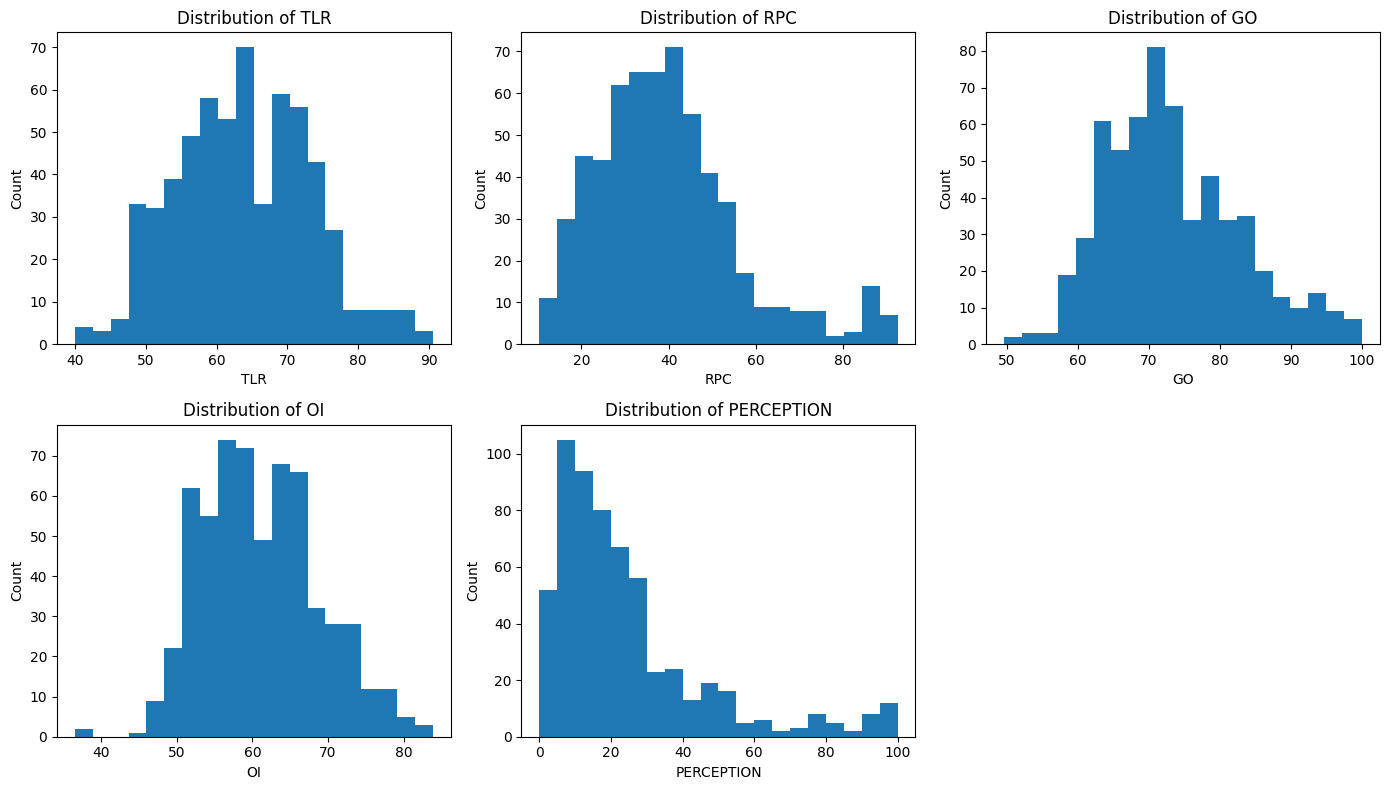

In [25]:
import matplotlib.pyplot as plt

params = ["tlr", "rpc", "go", "oi", "perception"]

plt.figure(figsize=(14,8))
for i, col in enumerate(params, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col.upper()}")
    plt.xlabel(col.upper())
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [26]:
df[params].std().sort_values(ascending=False)


perception    21.761667
rpc           16.509998
go             9.536223
tlr            9.437613
oi             7.678094
dtype: float64

**Higher std = more variability = more competition = more differentiation**

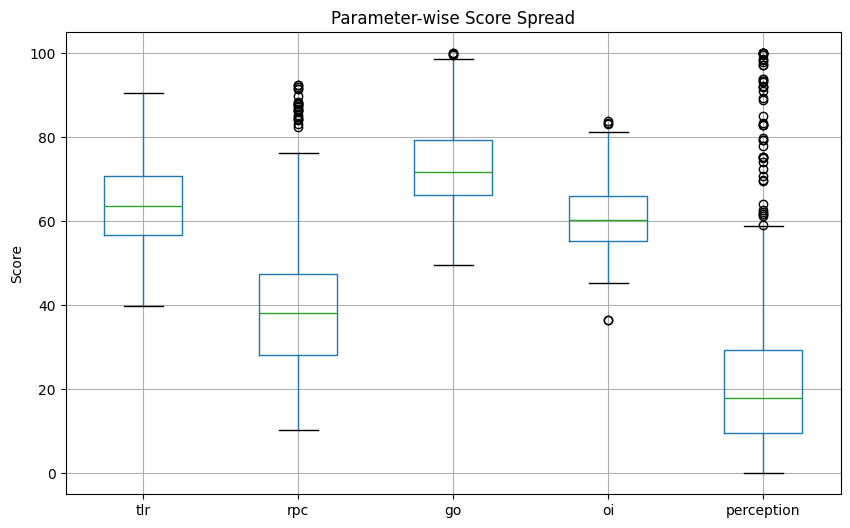

In [27]:
plt.figure(figsize=(10,6))
df[params].boxplot()
plt.title("Parameter-wise Score Spread")
plt.ylabel("Score")
plt.show()


**Analysis of individual NIRF parameters reveals significant differences in variability and competitiveness.**
**Research (RPC) and Perception show the highest variation, indicating that they play a major role in differentiating elite institutions.**
**In contrast, Teaching (TLR), Graduation Outcomes (GO), and Outreach (OI) exhibit relatively stable distributions, suggesting that most universities perform similarly in these areas.**
**This highlights that while baseline quality is widespread, research excellence and reputation are key drivers of top rankings.**

**Research (RPC) and Perception show the highest variation, indicating that they play a major role in differentiating elite institutions.**

## Teaching vs Research

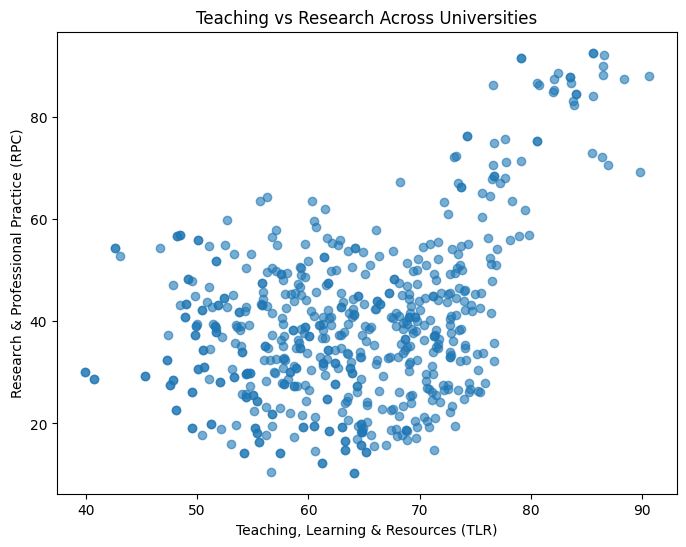

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(df["tlr"], df["rpc"], alpha=0.6)
plt.xlabel("Teaching, Learning & Resources (TLR)")
plt.ylabel("Research & Professional Practice (RPC)")
plt.title("Teaching vs Research Across Universities")
plt.show()


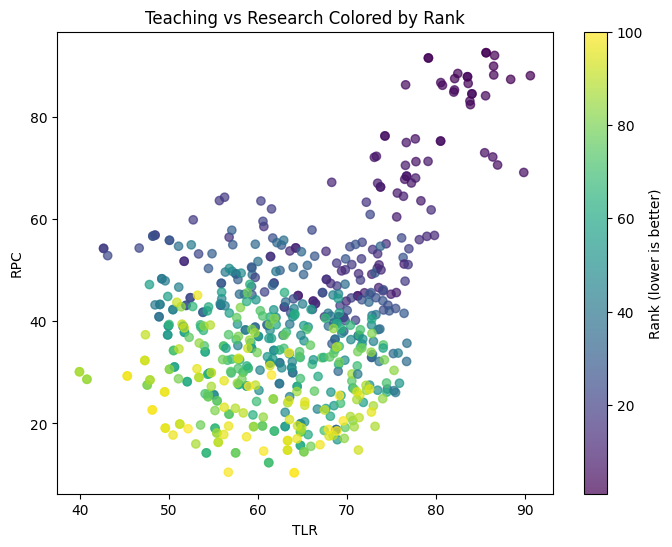

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["tlr"],
    df["rpc"],
    c=df["rank"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar(label="Rank (lower is better)")
plt.xlabel("TLR")
plt.ylabel("RPC")
plt.title("Teaching vs Research Colored by Rank")
plt.show()


## Correlation & Influence Analysis

**Which parameters have the strongest relationship with the final NIRF Score?**

In [30]:
corr_score = df[
    ["tlr", "rpc", "go", "oi", "perception", "score"]
].corr()["score"].sort_values(ascending=False)

corr_score


score         1.000000
rpc           0.901862
perception    0.853507
tlr           0.697297
go            0.535129
oi            0.185705
Name: score, dtype: float64

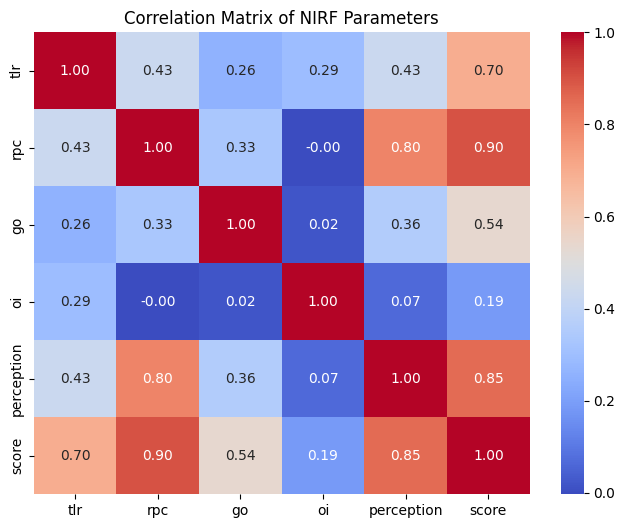

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df[["tlr", "rpc", "go", "oi", "perception", "score"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of NIRF Parameters")
plt.show()


**Which parameters are associated with better ranks?**

In [32]:
corr_rank = df[
    ["tlr", "rpc", "go", "oi", "perception", "rank"]
].corr()["rank"].sort_values()

corr_rank


rpc          -0.795417
perception   -0.695757
go           -0.535359
tlr          -0.468290
oi           -0.144431
rank          1.000000
Name: rank, dtype: float64


**Correlation analysis reveals that research performance (RPC) is the strongest driver of both NIRF score and rank, followed closely by institutional perception.**

**Teaching quality (TLR) and graduation outcomes (GO) play important but secondary roles, while outreach and inclusivity (OI) show limited influence on ranking outcomes.**

**These results indicate that while baseline academic quality is widespread, research excellence and reputation are the key differentiators among top-ranked institutions.**

## Year-wise Trends & Stability

**Are universities, on average, performing better over time?**

In [33]:
yearly_avg_score = df.groupby("year")["score"].mean()

yearly_avg_score


year
2020    51.1514
2021    51.1514
2022    53.6463
2023    55.1119
2024    56.7559
2025    57.7612
Name: score, dtype: float64

**This suggests increasing competition and gradual strengthening of academic and research capabilities over time**

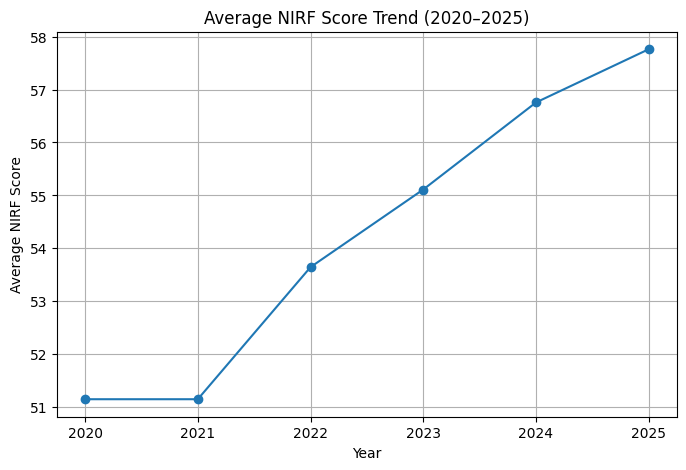

In [34]:
plt.figure(figsize=(8,5))
plt.plot(yearly_avg_score.index, yearly_avg_score.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average NIRF Score")
plt.title("Average NIRF Score Trend (2020–2025)")
plt.grid(True)
plt.show()


In [35]:
top10_each_year = (
    df[df["rank"] <= 10]
    .groupby("year")["institute_name"]
    .apply(list)
)

top10_each_year


year
2020    [Indian Institute of Technology Madras, Indian...
2021    [Indian Institute of Technology Madras, Indian...
2022    [Indian Institute of Technology Madras, Indian...
2023    [Indian Institute of Technology Madras, Indian...
2024    [Indian Institute of Technology Madras, Indian...
2025    [Indian Institute of Technology Madras, Indian...
Name: institute_name, dtype: object

In [36]:
top10_each_year.loc[2020]


['Indian Institute of Technology Madras',
 'Indian Institute of Science',
 'Indian Institute of Technology Bombay',
 'Indian Institute of Technology Delhi',
 'Indian Institute of Technology Kanpur',
 'Indian Institute of Technology Kharagpur',
 'Indian Institute of Technology Roorkee',
 'Indian Institute of Technology Guwahati',
 'Jawaharlal Nehru University',
 'Banaras Hindu University']

In [37]:
top10_each_year.loc[2023]


['Indian Institute of Technology Madras',
 'Indian Institute of Science',
 'Indian Institute of Technology Delhi',
 'Indian Institute of Technology Bombay',
 'Indian Institute of Technology Kanpur',
 'All India Institute of Medical Sciences, Delhi',
 'Indian Institute of Technology Kharagpur',
 'Indian Institute of Technology Roorkee',
 'Indian Institute of Technology Guwahati',
 'Jawaharlal Nehru University']

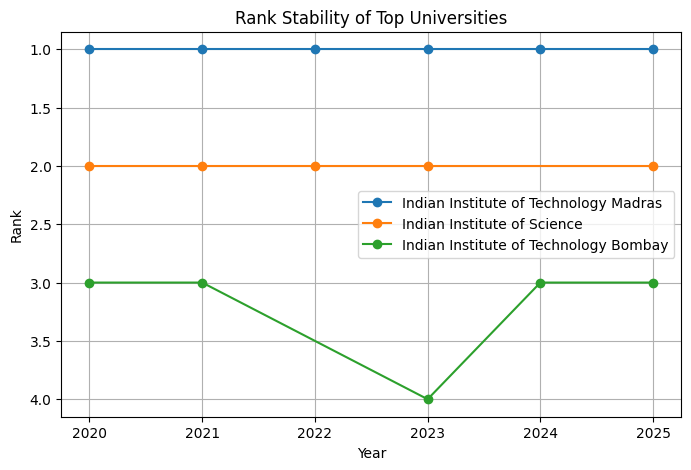

In [38]:
top_institutes = [
    "Indian Institute of Technology Madras",
    "Indian Institute of Science",
    "Indian Institute of Technology Bombay"
]

plt.figure(figsize=(8,5))

for inst in top_institutes:
    temp = df[df["institute_name"] == inst]
    plt.plot(temp["year"], temp["rank"], marker="o", label=inst)

plt.gca().invert_yaxis()
plt.xlabel("Year")
plt.ylabel("Rank")
plt.title("Rank Stability of Top Universities")
plt.legend()
plt.grid(True)
plt.show()


**Which universities have the most volatile rankings?**

In [39]:
rank_volatility = (
    df.groupby("institute_name")["rank"]
    .std()
    .sort_values(ascending=False)
)

rank_volatility.head(10)


institute_name
Savitribai Phule Pune University       26.966646
Mysore University                      22.895414
Bharathiar University                  20.925264
Chandigarh University                  20.566153
Lovely Professional University         16.899704
Tata Institute of Social Sciences      16.459546
Institute of Chemical Technology       16.208023
Mahatma Gandhi University, Kottayam    15.885003
Andhra University, Visakhapatnam       15.610894
Banasthali Vidyapith                   15.556349
Name: rank, dtype: float64

**Rank volatility analysis shows that mid-ranked universities experience significant year-to-year fluctuations, while top-ranked institutions remain remarkably stable.**

# EDA Conclusion

<div style="padding: 15px; border-left: 5px solid #2e7d32; background-color: #f1f8e9; color: #1b5e20; border-radius: 4px; line-height: 1.6;">
<strong style="font-size: 1.2em;"> NIRF Ranking Dynamics</strong>

<strong>NIRF rankings reward sustained research excellence and reputation</strong>, <strong>while teaching quality ensures baseline competitiveness.</strong>

<strong style="font-size: 1.1em;">📈 Key Driver</strong>
<strong>Rank volatility arises primarily from intense competition among mid-ranked institutions.</strong>
</div>



# Feature selection & target definition

**Since NIRF rank is derived from the overall score and is highly sensitive to small score changes, we model the problem as a regression task to predict the NIRF score rather than the rank.**

In [40]:
features = ["tlr", "rpc", "go", "oi", "perception"]
target = "score"


In [41]:
X = df[features]
y = df[target]

X.head(), y.head()


(     tlr    rpc     go     oi  perception
 0  85.61  92.51  86.32  63.57       97.13
 1  79.13  91.48  78.23  58.39      100.00
 2  83.52  87.81  80.86  57.48       91.96
 3  84.02  84.46  75.07  67.97       93.89
 4  80.50  75.23  80.74  56.97       79.30,
 0    86.76
 1    82.67
 2    82.52
 3    81.75
 4    76.50
 Name: score, dtype: float64)

# Train Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline Model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)



In [44]:
rmse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

rmse_lr, r2_lr


(4.852223753024009e-05, 0.9999993805281034)

In [45]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coef_df


,feature,coefficient
0,tlr,0.300063
1,rpc,0.299950
2,go,0.200007
3,oi,0.100006
4,perception,0.100004


**demonstrates that the model has effectively reconstructed the NIRF scoring formula, providing strong explainability and confidence in the data quality.**

## Baseline Model Results (Linear Regression)

The Linear Regression model achieves an almost perfect fit, with an R² score close to 1 and a negligible RMSE.  
This result is expected, as the NIRF score is a weighted linear combination of the evaluation parameters used as input features.

Rather than indicating overfitting, this confirms the internal consistency of the dataset and validates the official NIRF scoring methodology.


# Insights from NIRF Ranking Analysis

### Why NIRF Ranking is Transparent
The NIRF ranking framework is transparent because it is based on clearly defined and publicly available evaluation parameters.  
Each university is assessed using fixed weights assigned to Teaching, Research, Graduation Outcomes, Outreach, and Perception.  
Since the final score is a weighted combination of these parameters, institutions can clearly understand how their performance translates into rankings.  
Our analysis confirms this transparency by accurately reconstructing the NIRF scoring mechanism using a simple linear model.

---

### What Universities Should Improve
The analysis shows that not all parameters contribute equally to ranking outcomes.  
Universities aiming to improve their NIRF rank should prioritize strengthening their **research output and professional practice**, as this has the strongest impact on scores.  
Improving teaching quality and graduation outcomes is essential to maintain baseline competitiveness, but significant rank advancement typically requires sustained research excellence and visibility.

---

### Why Research Dominates Rankings
Research performance dominates NIRF rankings because it exhibits the highest variability and strongest correlation with the final score.  
Only a small number of institutions achieve very high research scores, which creates clear separation at the top of the rankings.  
This makes research output a key differentiator, while other parameters primarily ensure minimum quality standards rather than elite positioning.

---

### Limitations of the Ranking System
While NIRF provides a structured and transparent evaluation framework, it has certain limitations.  
The ranking system heavily favors research-intensive institutions, which can disadvantage universities with strong teaching focus but limited research infrastructure.  
Additionally, perception-based scores introduce subjectivity, and small score differences can lead to large rank changes, especially among mid-ranked institutions.  
As a result, rankings should be interpreted as comparative indicators rather than absolute measures of institutional quality.
